# Before your start:

    Read the README.md file
    Comment as much as you can and use the resources (README.md file)
    Happy learning!

In this exercise, we  will generate random numbers from the continuous disributions we learned in the lesson. There are two ways to generate random numbers:

1. Using the numpy library 
1. using the Scipy library 

Use either or both of the lbraries in this exercise.

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
import seaborn as sns
from scipy import stats

## Uniform Distribution

To generate uniform random numbers between any two given values using scipy, we can either use the following code or the code that we have
discussed in class:

In [ ]:
# stats.uniform()
import random
def uniform_dist(bottom, ceiling, count):
    dist = ceiling-bottom
    result = np.empty(count)
    for i in range(count):
        result[i] = bottom + dist * random.random()
    return result


**Your task:**

1. Based on the code above, write a function that generates uniformly distributed random numbers. There are several requirements for your function:
    * It should accept 3 parameters: 
        * `bottom` - the lower boundary of the generated numbers
        * `ceiling` - the upper boundary of the generated numbers
        * `count` - how many numbers to generate
    * It should return an array of uniformly distributed random numbers

1. Call your function with 2 sets of params below:
    * bottom=10, ceiling=15, count=100
    * bottom=10, ceiling=60, count=1,000

1. Plot the uniform distributions generated above using histograms, where x axis is the value and y axis is the count. Let the histogram's number of bins be 10.

Your output should look like below:

![uniform distribution](ud.png)

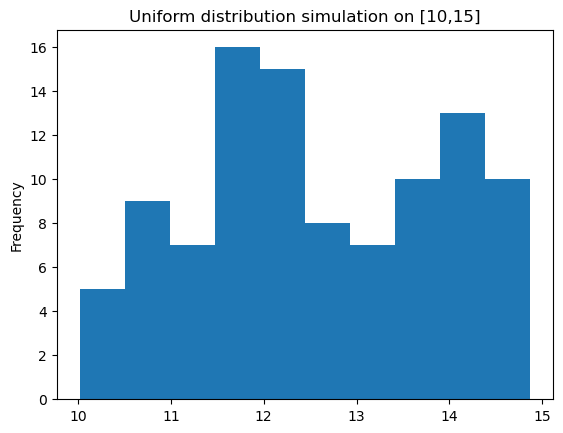

In [13]:
x1 = uniform_dist(10, 15, 100)
plt.hist(x1, bins=10)
plt.title('Uniform distribution simulation on [10,15]')
plt.xlabel('')
plt.ylabel('Frequency')
plt.show()

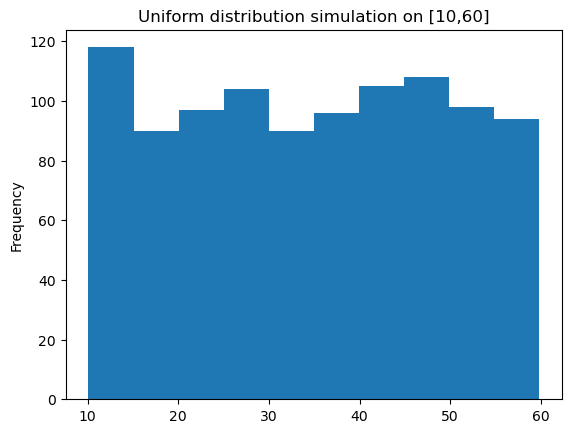

In [16]:
x2 = uniform_dist(10, 60, 1000)
plt.hist(x2, bins=10)
plt.title('Uniform distribution simulation on [10,60]')
plt.xlabel('')
plt.ylabel('Frequency')
plt.show()

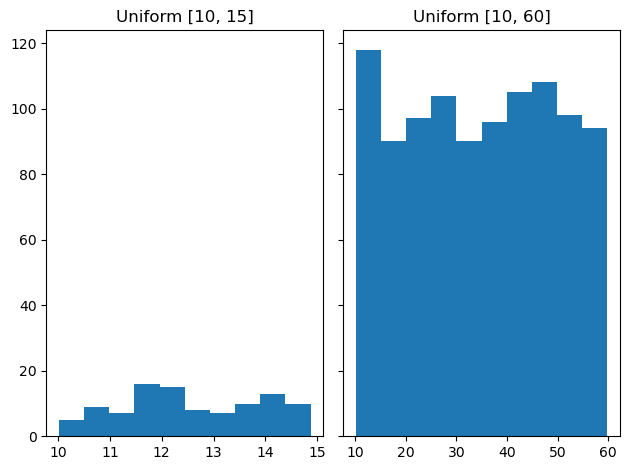

In [18]:
# Both plots in one image:
fig, axes = plt.subplots(1, 2, sharey=True)

# Plot 1
axes[0].hist(x1, bins=10)
axes[0].set_title('Uniform [10, 15]')

# Plot 2
axes[1].hist(x2, bins=10)
axes[1].set_title('Uniform [10, 60]')

plt.tight_layout()
plt.show()

How are the two distributions different?

In [ ]:
# The two distributions differ in the interval they cover and their density-level 
# (the more the probability mass is stretched across an interval, the lower the level of probability density is.)

## Normal Distribution

1. In the same way in the Uniform Distribution challenge, write a function that generates normally distributed random numbers.
1. Generate 1,000 normally distributed numbers with the average of 10 and standard deviation of 1
1. Generate 1,000 normally distributed numbers with the average of 10 and standard deviation of 50
2. Plot the distributions of the data generated.

Expected output:

![normal distribution](nd.png)

In [34]:
from scipy.stats import norm
def norm_dist(mu, sigma, n):
    return norm.rvs(loc=mu, scale=sigma, size=n)

In [35]:
x1_norm = norm_dist(10, 1, 1000)
x2_norm = norm_dist(10, 50, 1000)

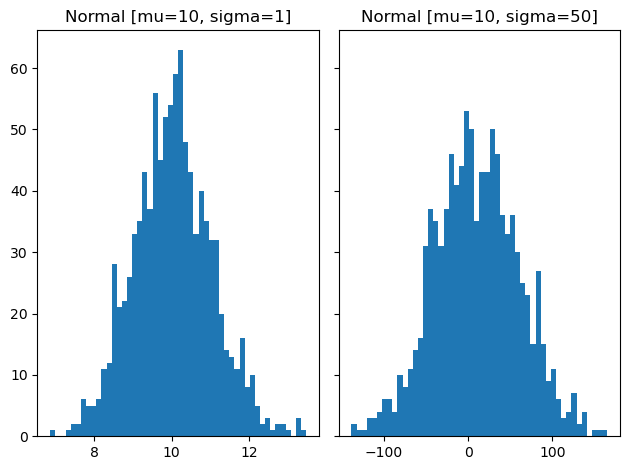

In [ ]:
# Both plots in one image:
fig, axes = plt.subplots(1, 2, sharey=True)

# Plot 1
axes[0].hist(x1_norm, bins=50)
axes[0].set_title('Normal [mu=10, sigma=1]')

# Plot 2
axes[1].hist(x2_norm, bins=50)
axes[1].set_title('Normal [mu=10, sigma=50]')

plt.tight_layout()
plt.show()

How are the two distributions different?

## Normal Distribution of Real Data

In this challenge we are going to take a look the real data. We will use vehicles.csv file for this exercise

In [38]:
vehicles = pd.read_csv("vehicles.csv")

First import vehicles.csv.
Then plot the histograms for the following variables:

1. Fuel Barrels/Year

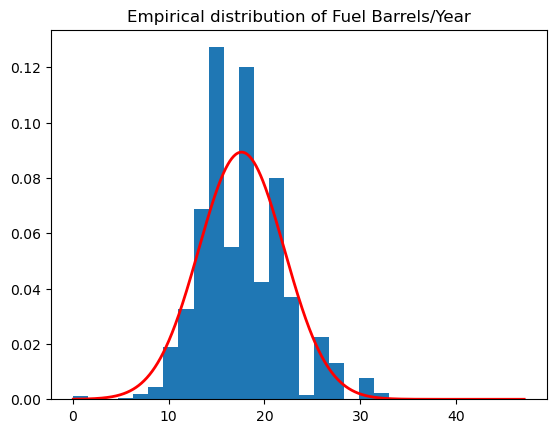

In [46]:
plt.hist(vehicles["Fuel Barrels/Year"], bins=30, density=True)
plt.title("Empirical distribution of Fuel Barrels/Year")

x_values = np.linspace(min(vehicles["Fuel Barrels/Year"]), max(vehicles["Fuel Barrels/Year"]), 1000)
pdf_values = norm.pdf(x_values, vehicles["Fuel Barrels/Year"].mean(), vehicles["Fuel Barrels/Year"].std())

plt.plot(x_values, pdf_values, 'r-', lw=2, label='Normal Distribution PDF')
plt.show()

2. CO2 Emission Grams/Mile 

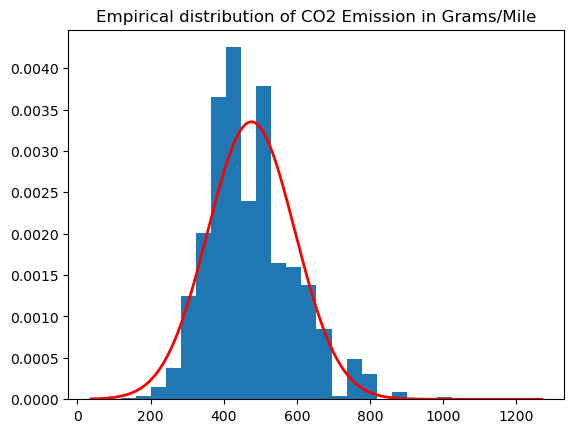

In [45]:
plt.hist(vehicles["CO2 Emission Grams/Mile"], bins=30, density=True)
plt.title("Empirical distribution of CO2 Emission in Grams/Mile")

x_values = np.linspace(min(vehicles["CO2 Emission Grams/Mile"]), max(vehicles["CO2 Emission Grams/Mile"]), 1000)
pdf_values = norm.pdf(x_values, vehicles["CO2 Emission Grams/Mile"].mean(), vehicles["CO2 Emission Grams/Mile"].std())

plt.plot(x_values, pdf_values, 'r-', lw=2, label='Normal Distribution PDF')
plt.show()

3. Combined MPG

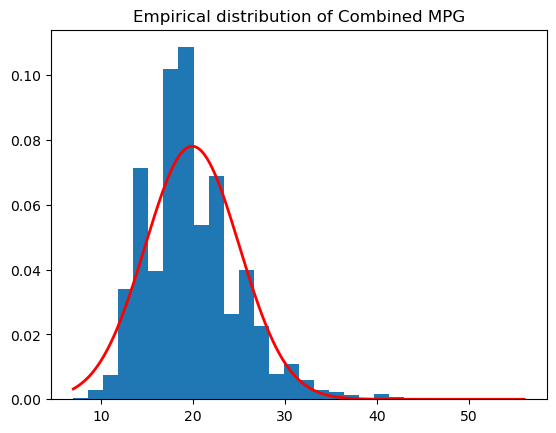

In [44]:
plt.hist(vehicles["Combined MPG"], bins=30, density=True)
plt.title("Empirical distribution of Combined MPG")

x_values = np.linspace(min(vehicles["Combined MPG"]), max(vehicles["Combined MPG"]), 1000)
pdf_values = norm.pdf(x_values, vehicles["Combined MPG"].mean(), vehicles["Combined MPG"].std())

plt.plot(x_values, pdf_values, 'r-', lw=2, label='Normal Distribution PDF')
plt.show()

Which one(s) of the variables are nearly normally distributed? How do you know?

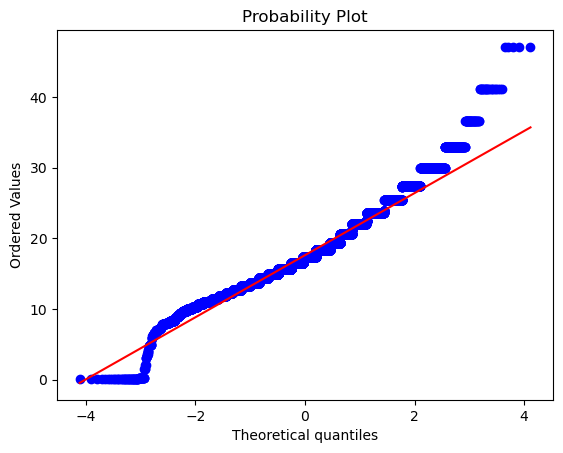

In [48]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(vehicles["Fuel Barrels/Year"], dist="norm", plot=plt)
plt.show()

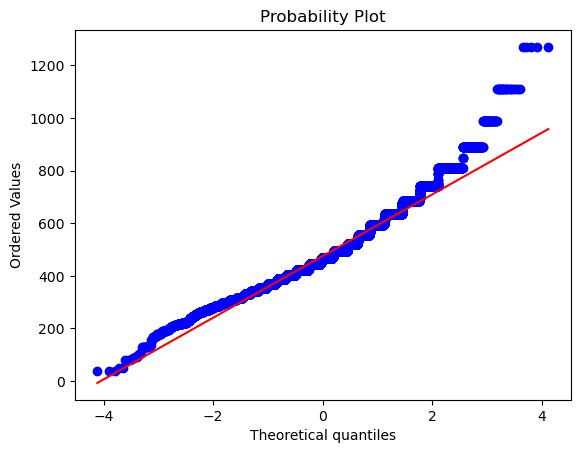

In [50]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(vehicles["CO2 Emission Grams/Mile"], dist="norm", plot=plt)
plt.show()

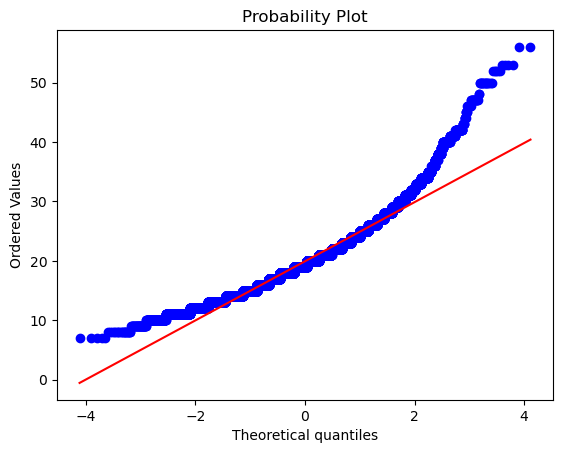

In [51]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(vehicles["Combined MPG"], dist="norm", plot=plt)
plt.show()

None of them are normally ditributed. 

## Exponential Distribution

1. Using `numpy.random.exponential`, create a function that returns a list of numbers exponentially distributed with the mean of 10. 

1. Use the function to generate two number sequences with the size of 10 and 100.

1. Plot the distributions as histograms with the nubmer of bins as 100.

Your output should look like below:

![exponential distribution](ed.png)

In [66]:
def exp_dist(scale, n):
    result = []
    for i in range(n):
        result.append(np.random.exponential(scale))
    return result

In [ ]:
scale = 10
# Assumption: larger sample size is justified because otherwise bins=100 does not make sense to me.
x1_exp = exp_dist(scale, 1000)
x2_exp = exp_dist(scale, 10000)

In [64]:
x1_exp

[0.8511713951806206,
 0.4665845503445598,
 7.265141785733277,
 0.0194549918352354,
 1.6655127824520295,
 3.3441029749656415,
 9.156703229236335,
 11.335252216268117,
 8.339265883057347,
 0.03206158013883183]

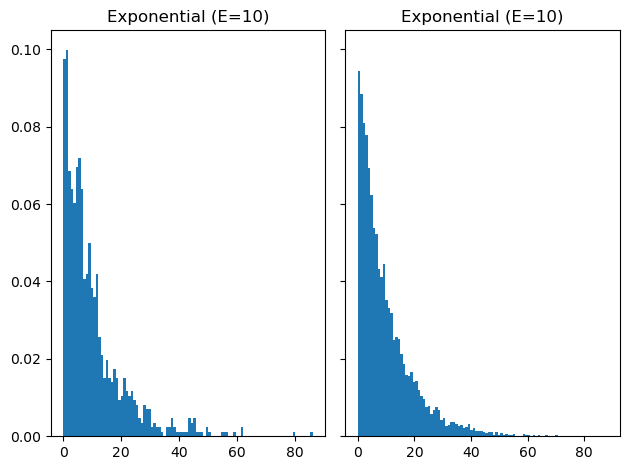

In [ ]:
# Both plots in one image:
fig, axes = plt.subplots(1, 2, sharey=True)

# Plot 1
axes[0].hist(x1_exp, bins=100, density=True)
axes[0].set_title('Exponential (E=10)')

# Plot 2
axes[1].hist(x2_exp, bins=100, density=True)
axes[1].set_title('Exponential (E=10)')

plt.tight_layout()
plt.show()

How are the two distributions different?

The mean changes, so the distribution changes as well. 

## Exponential Distribution of Real Data

Suppose that the amount of time one spends in a bank is exponentially distributed with mean as 10 minutes (i.e. λ = 1/10). What is the probability that a customer will spend less than fifteen minutes in the bank? 

Write a code in python to solve this problem

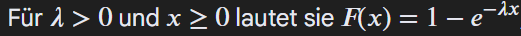

In [74]:
def exp_cdf(lam, x):
    if x < 0:
        return 0
    else:
        return 1-math.exp(-lam * x)

In [76]:
# Hint: This is same as saying P(x<15)
p = exp_cdf(1/10, 15)

What is the probability that the customer will spend more than 15 minutes

In [77]:
1-p

0.2231301601484298